In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os


In [2]:
binned_weight_32 = {2: [{2: {0.05: 223, 0.15: 1, 1.0: 5776}, 3: {1.0: 6000}},
  {2: {0.05: 5200, 0.45: 1, 1.0: 799},
   3: {0.05: 5215, 0.15: 1, 0.25: 1, 1.0: 783}},
  {2: {0.05: 5203, 0.5: 1, 1.0: 796},
   3: {0.05: 5381, 0.1: 1, 0.45: 1, 1.0: 617}},
  {2: {0.05: 5575, 0.4: 1, 1.0: 424}, 3: {0.05: 5303, 0.2: 1, 1.0: 696}},
  {2: {0.05: 5308, 0.9: 1, 1.0: 691},
   3: {0.05: 5284, 0.25: 1, 0.7: 1, 1.0: 714}}],
 3: [{4: {1.0: 6000}, 5: {0.05: 3011, 0.75: 1, 1.0: 2988}},
  {4: {0.05: 5575, 0.55: 1, 1.0: 424}, 5: {0.05: 5846, 0.8: 1, 1.0: 153}},
  {4: {0.05: 5381, 0.25: 1, 0.35: 1, 1.0: 617},
   5: {0.05: 5879, 0.15: 1, 1.0: 120}},
  {4: {0.05: 5382, 0.1: 1, 1.0: 617}, 5: {0.05: 5820, 0.85: 1, 1.0: 179}},
  {4: {0.05: 5294, 0.1: 1, 0.95: 1, 1.0: 704},
   5: {0.05: 5821, 0.1: 1, 1.0: 178}}],
 4: [{6: {1.0: 6000}, 7: {1.0: 6000}},
  {6: {0.05: 5654, 0.1: 1, 0.65: 1, 0.7: 1, 1.0: 343},
   7: {0.05: 5883, 1.0: 117}},
  {6: {0.05: 5609, 0.25: 1, 0.35: 1, 0.65: 1, 0.8: 1, 1.0: 387},
   7: {0.05: 6000}},
  {6: {0.05: 5416, 0.95: 1, 1.0: 583}, 7: {0.05: 5804, 0.2: 1, 1.0: 195}},
  {6: {0.05: 5368, 0.1: 1, 0.3: 1, 1.0: 630},
   7: {0.05: 5872, 0.9: 1, 1.0: 127}}],
 5: [{8: {0.05: 400, 1.0: 5600}, 9: {0.05: 18, 1.0: 5982}},
  {8: {0.05: 5473, 0.65: 1, 1.0: 526},
   9: {0.05: 5640, 0.3: 1, 0.6: 1, 1.0: 358}},
  {8: {0.05: 5416, 0.2: 2, 1.0: 582},
   9: {0.05: 5314, 0.15: 1, 0.3: 1, 0.35: 1, 1.0: 683}},
  {8: {0.05: 5499, 0.15: 1, 0.6: 1, 1.0: 499},
   9: {0.05: 5276, 0.1: 1, 0.9: 1, 0.95: 1, 1.0: 721}},
  {8: {0.05: 5463, 0.5: 1, 0.6: 2, 0.65: 1, 1.0: 533},
   9: {0.05: 5278, 0.6: 1, 1.0: 721}}]}

In [3]:
# colors = ['#1f77b4', '#ffbe84', '#2ca02c', '#d62728', '#9467bd']  # Colorblind-safe colors
hatch_patterns = ['////', '\\\\\\\\']

# MNIST / FashionMNIST
y_lim = 13000
# y_lim = 800

def dict_to_hist(d, eps = 10E-5):
    out = list()
    for k in d:
        out.extend([k-eps]*d[k])
    return out

def merge(src, app):
    for d in app:
        src[d] = src.get(d, dict())
        for k in app[d]:
            src[d][k] = src[d].get(k, 0) + app[d][k]
        

def merge_dict(list_dict, avg=False, round=True):
    out = dict()
    for d in list_dict:
        merge(out, d)
    if avg:
        for k1 in out:
            for k2 in out[k1]:
                out[k1][k2] /= len(list_dict)
                if round:
                    out[k1][k2] = np.round(out[k1][k2])
                    out[k1][k2] = int(out[k1][k2])
                else:
                    out[k1][k2] = np.round(out[k1][k2], 3)

    return out

def draw_plot(weight_dict, label, num_bin=20):
    num_epochs=15
    bins = np.arange(0, 1+1/num_bin, 1/num_bin)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams['pdf.fonttype'] = 42
    plt.rc('font', size=20)
    plt.rc('axes', labelsize=20)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.rc('legend', fontsize=15)
    plt.rc('figure', titlesize=20)
    num_1_list = list()
    for t in range(1+1, 5+1):
        for e in range(num_epochs):
            num_1 = 0
            for i, dv in enumerate(weight_dict[t][e].values()):
                for k in dv:
                    if k != 0.05:
                        num_1+=dv[k]
            num_1_list.append(num_1)
    plt.plot(range(num_epochs+1, num_epochs*5+1), num_1_list, "o-", label=label)

    plt.axvline(x=num_epochs*2, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=num_epochs*3, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=num_epochs*4, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=num_epochs*5, color = "black", linewidth=1.5, linestyle="dashed")

    plt.text(num_epochs*1.5, -1500, 'Task 2', ha='center', va='bottom', fontsize=20)
    plt.text(num_epochs*2.5, -1500, 'Task 3', ha='center', va='bottom', fontsize=20)
    plt.text(num_epochs*3.5, -1500, 'Task 4', ha='center', va='bottom', fontsize=20)
    plt.text(num_epochs*4.5, -1500, 'Task 5', ha='center', va='bottom', fontsize=20)


    # plt.hist([dict_to_hist(x) for x in weight_dict.values()], bins, stacked=True, \
    #             edgecolor='black', histtype='bar', label=list(weight_dict.keys()))
    # plt.xlim([0, 1])
    # # plt.ylim([0, y_lim])
    plt.ylabel('Number of non-zero weights')
    plt.xticks(range(num_epochs*1+1, num_epochs*5+1), [])
    # plt.legend(loc='upper center')
    # # plt.axvline(drop_threshold, color='black', linestyle='dashed')
    # plt.show()
    # plt.clf()

def draw_plot_bar(weight_dict, label, num_bin=20, y_axis = False):
    dataset = "MNIST"
    if dataset in ["MNIST", "FashionMNIST"]:
        label = [f"Class {g}" for g in list(weight_dict.keys())]
    else:
        label = [f"Sens. {g}" for g in list(weight_dict.keys())]
    bins = np.arange(0, 1+1/num_bin, 1/num_bin)
    plt.figure(figsize=(3, 2))
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams['pdf.fonttype'] = 42
    plt.rc('font', size=15)
    plt.rc('axes', labelsize=15)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.rc('legend', fontsize=15)
    plt.rc('figure', titlesize=15)
    x = [np.round(x, 3) for x in np.arange(0.5/num_bin, 1+0.5/num_bin, 1/num_bin)]
    prev_y = np.zeros_like(x)
    for i, (k, v) in enumerate(weight_dict.items()):
        y = np.zeros_like(x)
        for x_, y_ in v.items():
            idx = x.index(np.round(x_ - 0.5/num_bin, 3))
            y[idx] += y_
        plt.bar(x, y, bottom=prev_y, edgecolor='black', width=1/num_bin, label=label[i], hatch=hatch_patterns[i])
        prev_y = y

    plt.xlim([-0.05, 1.05])
    plt.ylim([0, y_lim])
    plt.yticks([0, 5000, 10000])
    plt.xlabel('Weight')
    if y_axis:
        plt.ylabel('Number of samples')
    plt.legend(loc='upper center')
    # plt.axvline(drop_threshold, color='black', linestyle='dashed')
    
def merge_dicts(binned_w, avg=True, round=True):
    out_dict = dict()
    for t in binned_w:
        out_dict[t] = merge_dict(binned_w[t], avg=avg, round=round)
    return out_dict

def count_binary(bin):
    binary = 0
    non_binary = 0
    for cs in bin:
        for k in bin[cs]:
            if k in [0.05, 1.0]:
                binary += bin[cs][k]
            else:
                non_binary += bin[cs][k]
    binary = np.round(binary, 3)
    non_binary = np.round(non_binary, 3)
    return binary, non_binary


In [4]:
4%2

0

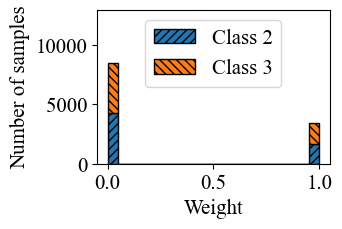

<Figure size 640x480 with 0 Axes>

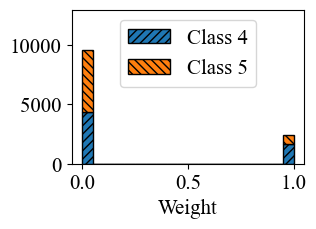

<Figure size 640x480 with 0 Axes>

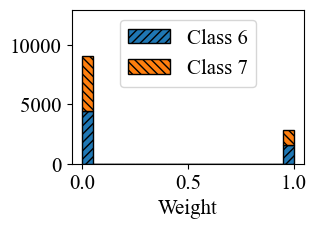

<Figure size 640x480 with 0 Axes>

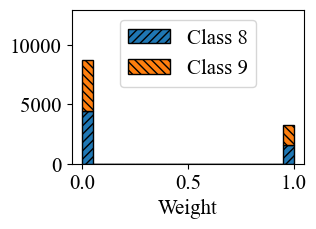

<Figure size 640x480 with 0 Axes>

In [5]:
s_g = 32 # number of samples for each group
bw = binned_weight_32 # binned_weight_{s_g}
for t in range(2, 6):
    draw_plot_bar(merge_dicts(bw)[t], label="FSW (buffer size/group = 16)", y_axis=(t==2))
    # draw_plot_bar(merge_dicts(bw)[t], label="FSW (buffer size/group = 16)", y_axis=(t%2==0))
    plt.savefig(f"weight_plot/FashionMNIST_EER_{s_g}_task_{t}.pdf", bbox_inches="tight")
    plt.show()
    plt.clf()
# draw_plot_bar(binned_weight_32, label="FSW (buffer size/group = 32)")
# draw_plot_bar(binned_weight_64, label="FSW (buffer size/group = 64)")
# draw_plot_bar(binned_weight_128, label="FSW (buffer size/group = 128)")

# plt.legend(bbox_to_anchor=(0., 1.1, 1., .1), loc='center',
#         ncol=2, borderaxespad=-0.1)

# plt.savefig(f"buf_weight.pdf", bbox_inches="tight")


In [6]:
s_g = 32 # number of samples for each group
bw = binned_weight_32 # binned_weight_{s_g}
b, nb = 0, 0
for t in bw.keys():
    count = count_binary(merge_dicts(bw, avg=True, round=False)[t])
    b += count[0]
    nb += count[1]
b/=len(bw)
nb/=len(bw)

print(f"& {b:.1f}")
print(f"& {nb:.1f}")

& 11997.4
& 2.6
